<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/Customer_Churn_Prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
pip install opendatasets

In [140]:
import opendatasets as od

In [141]:
od.download('https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv')

Skipping, found downloaded files in "./churn-modellingcsv" (use force=True to force download)


In [142]:
import pandas as pd

In [143]:
df = pd.read_csv('/content/churn-modellingcsv/Churn_Modelling.csv')

In [144]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4424,4425,15774630,Peacock,601,Germany,Female,47,1,142802.02,1,1,1,57553.02,0
7461,7462,15645571,Genovese,596,Spain,Male,32,4,0.00,2,0,1,146504.35,0
2500,2501,15713378,Brownless,711,France,Male,38,10,0.00,2,0,0,53311.78,0
1538,1539,15723411,Jamieson,607,Spain,Female,36,4,98266.30,1,1,1,46416.36,0
2047,2048,15814536,Conti,549,France,Male,37,2,112541.54,2,0,0,47432.43,0


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [148]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [149]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [150]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [151]:
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first=True)

In [152]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [153]:
from sklearn.model_selection import train_test_split

In [154]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [155]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [156]:
x_train.shape

(8000, 11)

In [157]:
from sklearn.preprocessing import StandardScaler

In [158]:
scaler = StandardScaler()

In [159]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [160]:
# x_train_scaled

In [161]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [162]:
model = Sequential()

In [163]:
model.add(Dense(12, activation='relu', input_dim=11))
model.add(Dense(6, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [164]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229 (916.00 B)

 Trainable params: 229 (916.00 B)

 Non-trainable params: 0 (0.00 B)

In [165]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [166]:
history = model.fit(x_train_scaled, y_train, epochs = 10, validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7949 - loss: 0.5421 - val_accuracy: 0.7987 - val_loss: 0.4719
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7840 - loss: 0.4847 - val_accuracy: 0.8100 - val_loss: 0.4411
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8001 - loss: 0.4479 - val_accuracy: 0.8194 - val_loss: 0.4287
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8041 - loss: 0.4441 - val_accuracy: 0.8263 - val_loss: 0.4189
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8218 - loss: 0.4221 - val_accuracy: 0.8300 - val_loss: 0.4078
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8254 - loss: 0.4213 - val_accuracy: 0.8375 - val_loss: 0.3983
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8340 - loss: 0.3985 - val_accuracy: 0.8381 - val_loss: 0.3888
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8436 - loss: 0.3873 - val_accuracy: 0.

In [167]:
model.layers[1].get_weights()

[array([[ 0.68005055,  0.74459696,  0.05762742,  0.12618661, -0.23822525,
         -0.19876927],
        [-0.2647612 , -0.62397295, -0.2498229 , -0.39296347,  0.0433322 ,
          0.10906932],
        [ 0.08220823, -0.116075  ,  0.07506953,  0.32347807,  0.6115195 ,
          0.6752194 ],
        [-0.09692138,  0.5378422 , -0.1758247 , -0.46127632,  0.46749038,
          0.2613066 ],
        [-0.4451463 , -0.44856137, -0.8087142 , -0.3614317 ,  0.09934266,
         -0.48661888],
        [ 0.41925576,  0.15210299, -0.17403449,  0.16205697,  0.3606265 ,
         -0.35933807],
        [ 0.02865906,  0.20246434,  0.4282866 ,  0.01047288,  0.59709734,
         -0.1737146 ],
        [ 0.12692411, -0.17376542, -0.2853653 ,  0.5565017 ,  0.6365277 ,
         -0.03337297],
        [ 0.18662144, -0.3118194 ,  0.30906457, -0.57227045,  0.5560159 ,
          0.2689281 ],
        [-0.8303188 ,  0.39809108, -0.06102911, -0.6221524 , -0.41837028,
         -0.52200156],
        [-0.46489236, -0.38561

In [168]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [169]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [170]:
fpr, tpr, thresholds = roc_curve(y_test, y_log)
roc_auc = auc(fpr, tpr)

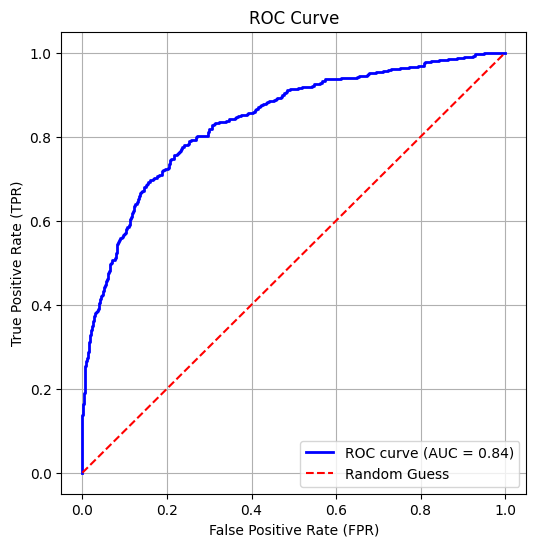

In [171]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [172]:
import numpy as np

In [173]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [174]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [175]:
from sklearn.metrics import accuracy_score

In [176]:
accuracy_score(y_test, y_pred)

0.851

In [177]:
accuracy_score(y_test, y_pred)

0.851

In [178]:
history

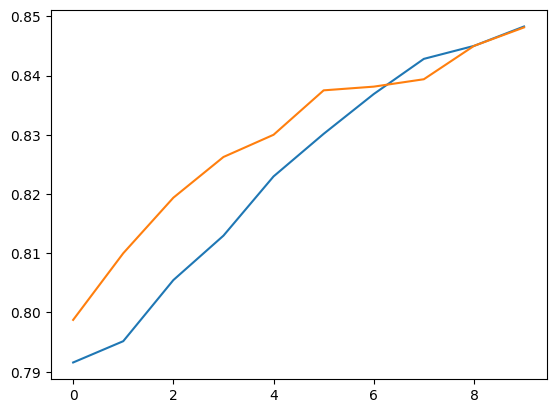

In [179]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

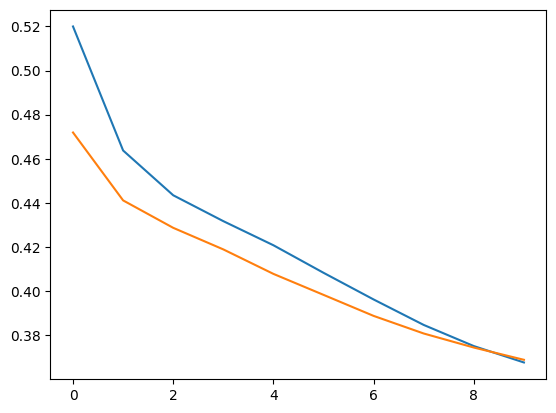

In [180]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])